### Supervised ML
- More data given to computer -> better it gets at its task
- Parabolic fitting, compressie -> ook voorbeelden van ML; meer data, betere performance.
- Deep learning: ML in lagen


Computer interacties: _Input_, _Functie_, _Output_.

in ML, computer leert de functie die input naar output mapt.

Bij supervised learning neemt het programma een input-output pair, en 'leert' de functie die ze mapt. Functie heet het _Model_.

### Basic terminology:
- _Features_: de input; de kolommen van de dataset; eg, type, naam, generation van een pokemon.
- _Labels:_ de Output, of target; het deel dat vergeleken wordt met de voorspelling van het model.
- _Example_: een enkel input/output paar
- _Dataset_: samenvoeging van vele examples
- _Prediction_: de output van het model dat de functie geleerd heeft, en op een nieuwe input zelf output voorspelt.

**Targets:**
- categorisch: qualitatief, eg. appels vs. peren. Subcategorieen: Nominaal (geen volgorde), Ordinaal (er is een volgorde).
- Numeriek: quantitatief, subcategorieen: Interval variabele (0 heeft geen betekenis), Ratio variabele (0 heeft een betekenis).

Categorical + Supervised = _Classficiation_
Categorical + Unsupervised = _Clustering_

Numerical + Supervised = _Regression_
Numerical + Unsupervised = _Dimensionality Reduction_

### Learning
- de functie leren vereist het sturen op _parameters_; zoeken naar de optimale set parameters heet _hyperparameter tuning_.
- Nadeel machine learning: het geeft _altijd_ een antwoord; maar het is aan mij om iets te zeggen over hoe _goed_ dat antwoord is.

In [55]:
import sklearn as skl
import numpy as np

In [3]:
data = skl.datasets.load_digits() # A dataset baked in with Scikit Learn
raw_X = data.data
y = data.target                   # Integer numbers --> we are classifying data here.
print(raw_X.shape, y.shape)

(1797, 64) (1797,)


In [37]:
X = raw_X                                        # Start with a bad example: training data is *all* data
model = skl.ensemble.RandomForestClassifier()    # Our model is the RandomForestClassifier -> go read the docs.
model.fit(X, y)                                  # Train the model on dataset X with supervisory targets y
yhat = model.predict(X)                          # Resubstitution -> predict based on X what y should be.
score1 = skl.metrics.f1_score(y, yhat, average='micro') # An f1 score, 0-1
score2 = skl.metrics.accuracy_score(y, yhat)            # different score method, 01
print(f'Cheated scores: {score1, score2}')

Cheated scores: (1.0, 1.0)


De accuratesse is 100%, maar dit komt omdat ons model de dataset als het ware gewoon onthouden heeft. We moeten het model eigenlijk testen met een nieuwe

In [12]:
# now first scale the complete dataset, then split it;
# that way the scaler learns about the test set (which is bad, but it's an example)
scaler = skl.preprocessing.StandardScaler()
X = scaler.fit_transform(raw_X) #no longer just X = raw_X
X_train, X_test, y_train, y_test = skl.model_selection.train_test_split(X, y) # test data is for validation; train data is what the
                                                                              # model trains on. By default, train_test_split takes
                                                                              # a 75 / 25 split: 75% train, 25% test.
print(X_train.shape, X_test.shape)

(1347, 64) (450, 64)


Hierboven gebruiken we 75% train, 25% test. Dit kun je specifying met de test_size en train_size parameters (float of int). Beetje nattevingerwerk, maar hoe groter de testfractie, hoe beter, maar hoe minder goed je model leert. 25/75 of 20/80 is prima voor een eerste ingeving.

In [39]:
model = skl.ensemble.RandomForestClassifier()
model.fit(X_train, y_train)                                    # Training the model on our training data
yhat = model.predict(X_test)                                   # Predict based on X_test
score_f1 = skl.metrics.f1_score(y_test, yhat, average='micro') # Compare with y_test
score_a = skl.metrics.accuracy_score(y_test, yhat)

print(f'(Still cheated) scores: {score_f1, score_a}') # Cheated, because the scaler has 'seen' the test data,
                                                      # which we should have kept separate until the very end.

(Still cheated) scores: (0.975, 0.975)


In [40]:
## Now something else: first we split, then we scale, then we train and test.
## So, first we split 25/75:
X_train, X_test, y_train, y_test = skl.model_selection.train_test_split(X, y)

## Scale the Training data and the Test Features
scaler = skl.preprocessing.StandardScaler()
scaler.fit(X_train)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Now train our model
model = skl.ensemble.RandomForestClassifier()
model.fit(X_train, y_train)

## make predictions
yhat = model.predict(X_test)

## Test the accuracy
score = skl.metrics.accuracy_score(y_test, yhat)
print(score)

0.9755555555555555


## In a pipeline

In [43]:
## Now we do it in a pipeline format: convenient for chaining transformers and estimators.
## We specify various hyperparameters of the model (RandomForestClassifier),
## which we may tune in order to attain a higher accuracy. However, each time this cell is executed,
## we get a new Train/Test split, giving a different accuracy score each time.

## The code below shows us all the hyperparameters of RandomForestClassifier that could be tuned:
model = skl.ensemble.RandomForestClassifier()
print(model.get_params())

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}


In [44]:
## Let's create a pipeline that chains our scalar and model, with various hyperparameters to tune.
X_train, X_test, y_train, y_test = skl.model_selection.train_test_split(raw_X, y)

model = skl.pipeline.make_pipeline(
    skl.preprocessing.StandardScaler(),
    skl.ensemble.RandomForestClassifier(
        n_estimators=75,
        criterion='gini',
        max_depth=20,
        min_samples_split=2,
        min_samples_leaf=1,
        min_weight_fraction_leaf=0.0,
        max_features=None,
        max_leaf_nodes=None,
        min_impurity_decrease=0.0,
    ),
)

model.fit(X_train, y_train)
yhat = model.predict(X_test)
score = skl.metrics.accuracy_score(y_test, yhat)
print(score)

0.9466666666666667


In [45]:
## Better to split in a separate cell; otherwise we can't tell if the changing accuracy is due to our tunings,
## or due to a different split each time.
X_train, X_test, y_train, y_test = skl.model_selection.train_test_split(raw_X, y)

In [47]:
## Execute this cell however many times you like; due to controlled behavior, it will return the same score each time.
model = skl.pipeline.make_pipeline(
    skl.preprocessing.StandardScaler(),
    skl.ensemble.RandomForestClassifier(
        n_estimators=200,
        criterion='gini',
        max_depth=50,
        min_samples_split=2,
        min_samples_leaf=1,
        min_weight_fraction_leaf=0.0,
        max_features=None,
        max_leaf_nodes=None,
        min_impurity_decrease=0.0,
        random_state=42                 #specify a random state, control random behavior of RandomForestClassifier
    ),
)

model.fit(X_train, y_train)
yhat = model.predict(X_test)
score = skl.metrics.accuracy_score(y_test, yhat)
print(score)

0.96


We can tune these parameters arbitrarily high BUT:
We are only validating with our test data; not with further test data.
We can't just keep splitting our precious training data to get more test data.

What we can do is something called Cross-fold validation. The idea is that we split as usual, but we split
our training data in N pieces. We train on N-1, validate with the last piece, and do this in each possible
combination. Afterward, we can take the average accuracy, and we still have the secure training data, for demo.

This ets computationally expensive; N5 or N4 splits are common.

In [48]:
## Let's now get better at this. We will create a grid of hyperparameters, and let the model tune these parameters for us,
## returning the set of hyperparameters that give the highest accuracy. We first split 20/80.
X_train, X_test, y_train, y_test = skl.model_selection.train_test_split(raw_X, y, test_size=0.2)

In [50]:
## We set up a model; RandomForestClassifier()
model = skl.pipeline.make_pipeline(
    skl.preprocessing.StandardScaler(),
    skl.ensemble.RandomForestClassifier()
)

## Now we instantiate a gridsearch, which will try all possible combination of the provided hyperparameters.
gridsearch = skl.model_selection.GridSearchCV(
    estimator=model,
    param_grid={
        'randomforestclassifier__n_estimators': [25, 50, 75, 100],
        'randomforestclassifier__criterion': ['gini', 'entropy'],
        'randomforestclassifier__max_depth': [None, 10],
        'randomforestclassifier__min_samples_split': [2],
        'randomforestclassifier__min_samples_leaf': [1],
        'randomforestclassifier__min_weight_fraction_leaf': [0.0],
        'randomforestclassifier__max_features': [None, "sqrt", "log2"],
        'randomforestclassifier__max_leaf_nodes': [None],
        'randomforestclassifier__min_impurity_decrease': [0.0],
    },
    cv=4,                                                               # Cross-fold validation
    scoring=skl.metrics.make_scorer(skl.metrics.f1_score, average='micro'),
    n_jobs=-1,                                                          # How many cores to run on. -1 runs it on all available.
)

## Now we fit the training data
gridsearch.fit(X_train, y_train)
best = gridsearch.best_estimator_
print(gridsearch.best_params_)
print(gridsearch.best_score_)

{'randomforestclassifier__criterion': 'gini', 'randomforestclassifier__max_depth': None, 'randomforestclassifier__max_features': 'sqrt', 'randomforestclassifier__max_leaf_nodes': None, 'randomforestclassifier__min_impurity_decrease': 0.0, 'randomforestclassifier__min_samples_leaf': 1, 'randomforestclassifier__min_samples_split': 2, 'randomforestclassifier__min_weight_fraction_leaf': 0.0, 'randomforestclassifier__n_estimators': 50}
0.9805033271432992


In [51]:
## Note that the test score given above is only the score as measured over all the training data.
## We now take our 20% test data out of the vault, and see how the model stacks up with these best parameters.
yhat = best.predict(X_test)
score = skl.metrics.f1_score(y_test, yhat, average='micro')
print(score)

0.9777777777777777


In [52]:
## We could also perform a little trick to add different classifiers, other than RandomForest as parameters
## to optimize over. So below we set up a dummy classifier, which will be replaced in the gridsearch with
## classifier functions of interest to us, and the model will tell us which one scored the highest.

model = skl.pipeline.Pipeline([
    ('scale', skl.preprocessing.StandardScaler()),
    ('clf', skl.dummy.DummyClassifier()),
])

print(model.get_params()) # Note that the DummyClassifier is now one of the parameters

{'memory': None, 'steps': [('scale', StandardScaler()), ('clf', DummyClassifier())], 'transform_input': None, 'verbose': False, 'scale': StandardScaler(), 'clf': DummyClassifier(), 'scale__copy': True, 'scale__with_mean': True, 'scale__with_std': True, 'clf__constant': None, 'clf__random_state': None, 'clf__strategy': 'prior'}


In [53]:
## We create a list of dictionaries, each dict containing the hyperparameters for a particular Classifier Function.
## Here we use RandomForestClassifier and Logistic Regression.

param_grid = [
    {
        'clf': [skl.ensemble.RandomForestClassifier()],
        'clf__n_estimators': [25, 50, 75, 100, 250],
        'clf__criterion': ['gini', 'entropy'],
        'clf__max_depth': [None, 10, 25],
        'clf__min_samples_split': [2],
        'clf__min_samples_leaf': [1],
        'clf__min_weight_fraction_leaf': [0.0],
        'clf__max_features': [None, "sqrt", "log2"],
        'clf__max_leaf_nodes': [None],
        'clf__min_impurity_decrease': [0.0],
    },
    {
        'clf': [skl.linear_model.LogisticRegression()],
        'clf__penalty': ['l1', 'l2', 'elasticnet'],
        'clf__C': [1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2, 1e3],
        'clf__class_weight': ['balanced'],
        'clf__l1_ratio': [0.5],
        'clf__solver': ['saga'],
    }

]

## Now set up the grid search as beefore
gridsearch = skl.model_selection.GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring=skl.metrics.make_scorer(skl.metrics.f1_score, average='micro'),
    n_jobs=-1
)

gridsearch.fit(X_train, y_train)
best = gridsearch.best_estimator_
print(gridsearch.best_params_)
print(gridsearch.best_score_)

{'clf': RandomForestClassifier(), 'clf__criterion': 'entropy', 'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__max_leaf_nodes': None, 'clf__min_impurity_decrease': 0.0, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__min_weight_fraction_leaf': 0.0, 'clf__n_estimators': 75}
0.9770421989934185


In [54]:
## Now lets throw it on our test data, and see how the score stacks up.
yhat = best.predict(X_test)
score = skl.metrics.f1_score(y_test, yhat, average='micro')
print(f'Final score: {score}')

Final score: 0.975


### Validation curve
Effectively a 1d Grid Search - vary the value of one parameter, and compare the train and test scores, to obtain information on the behaviour of the model as you vary said parameter.

In [56]:
best_model = gridsearch.best_estimator_
n_estimators = np.linspace(10, 250, 50, dtype=int)
train_scores, test_scores = skl.model_selection.validation_curve(
    best_model, X_train, y_train,
    param_name = 'clf__n_estimators',
    param_range = n_estimators,
    scoring = skl.metrics.make_scorer(skl.metrics.f1_score, average='micro'))

In [57]:
import matplotlib.pyplot as plt

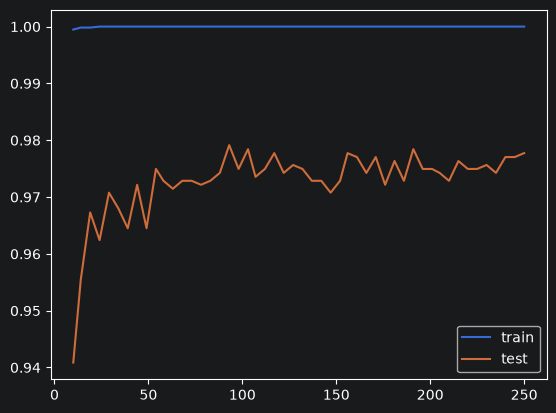

In [59]:
plt.plot(n_estimators, train_scores.mean(axis=1), label='train')
plt.plot(n_estimators, test_scores.mean(axis=1), label='test')
plt.legend()
plt.show()

We see that there is a sharp increase the f1 score as n_estimators goes to ~ 60, after which it starts to plateau. At n_estimators = 250, a higher score is attained, but we can ask ourselves if this is worth the additional computational budget.